<div style="padding:20px;color:white;font-size:240%;text-align:center;border-radius:5px;background-color:#023c66;font-weight:700;border:5px solid #F28C28;">Module 3 — Worksheet 1: Why and How We Reduce Dimensions</div>

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module 3:** Dimension Reduction  
**Focus:** Curse of dimensionality, categorical reduction, numeric redundancy, and feature selection

## Learning Goals

1. Explain the curse of dimensionality.
2. Connect model degrees of freedom to complexity.
3. Use business knowledge to screen variables.
4. Reduce high-cardinality categorical variables.
5. Use tree-based models to identify predictive categorical levels.
6. Identify redundant numeric predictors with correlation.
7. Distinguish feature selection from feature extraction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",100)
print("Ready!")

Ready!


## Roadmap

**Too many dimensions → screen variables → reduce categorical levels → remove redundancy → retain useful information**

This worksheet emphasizes practical dimension reduction before introducing PCA.

---
# 1. The Curse of Dimensionality

The number of predictors is the dimension $p$. As $p$ increases, observations become increasingly sparse.

Suppose $n=50$ observations are distributed across 5 regions per dimension.

- 1D: $50/5=10$ observations per region
- 2D: $50/5^2=2$
- 3D: $50/5^3=0.4$

As dimensions increase, **nothing is close to anything anymore**. Many predictive methods become more difficult because local neighborhoods contain fewer observations.

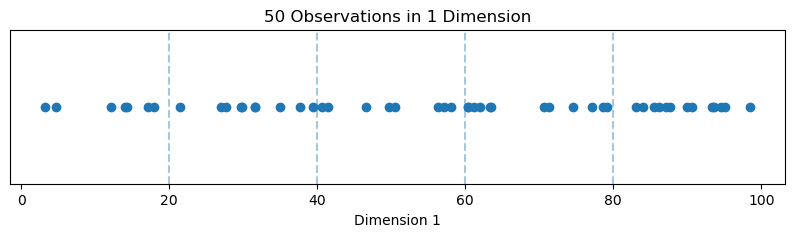

In [2]:
np.random.seed(591)
n=50
x=np.random.uniform(0,100,n)

plt.figure(figsize=(10,2))
plt.scatter(x,np.zeros(n))
plt.yticks([])
plt.xlabel("Dimension 1")
plt.title("50 Observations in 1 Dimension")
for b in [20,40,60,80]:
    plt.axvline(b,linestyle="--",alpha=.4)
plt.show()

### Interpretation

What happens to the density of the data as $p$ increases?

**Your response:**  
-

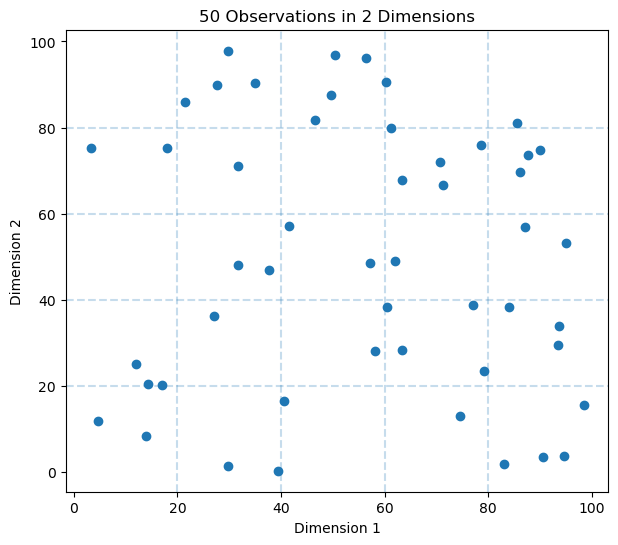

In [3]:
np.random.seed(591)
x1=np.random.uniform(0,100,n)
x2=np.random.uniform(0,100,n)

plt.figure(figsize=(7,6))
plt.scatter(x1,x2)
for b in [20,40,60,80]:
    plt.axvline(b,linestyle="--",alpha=.25)
    plt.axhline(b,linestyle="--",alpha=.25)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("50 Observations in 2 Dimensions")
plt.show()

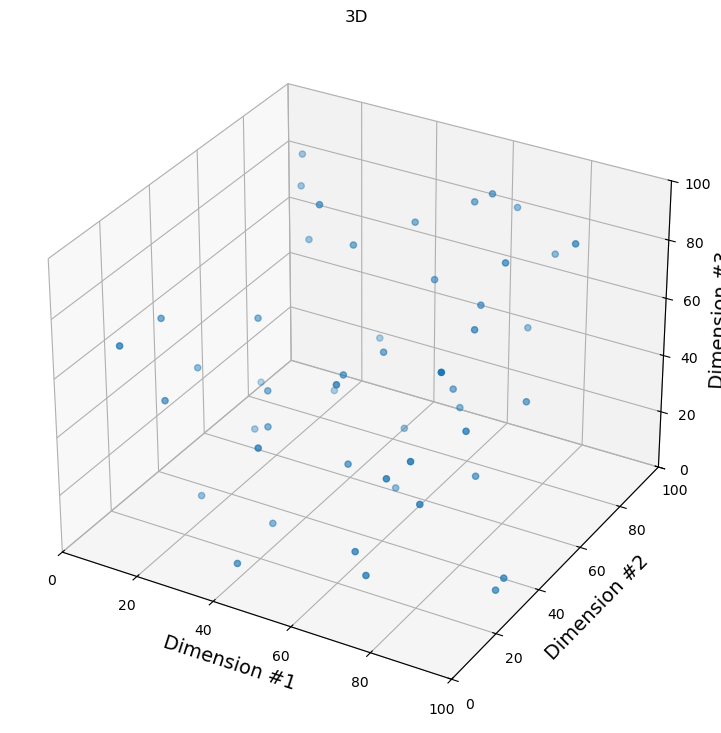

In [4]:
import random
from mpl_toolkits import mplot3d
fig = plt.figure(figsize = (13,9))
ax  = fig.add_subplot(1,1,1,projection='3d')
# fig.set_size_inches(10, 8)
# Now each point has 3 dimensions (x,y,x)
x = random.sample(range(0, 100), 50)
y = random.sample(range(0, 100), 50)
z = random.sample(range(0, 100), 50)
ax.scatter(x, y, z)
# Grid lines
for grid_pt in [20, 40, 60, 80]:
    plt.axvline(x=grid_pt, color='#D8D8D8')
    plt.axhline(y=grid_pt, color='#D8D8D8')
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.set_zlim(0,100)
ax.set_xlabel("Dimension #1", fontsize=14)
ax.set_ylabel("Dimension #2", fontsize=14)
ax.set_zlabel("Dimension #3", fontsize=14)
plt.title("3D")
plt.show()

---
# 2. Model Degrees of Freedom and Complexity

For linear/logistic models:

- numeric predictor → generally **1 df**
- categorical predictor with $k$ levels → generally **$k-1$ df** after dummy encoding

A single high-cardinality categorical predictor can therefore create substantial model complexity.

## Practice 2A — Calculate model df

In [5]:
# Age: numeric
# Income: numeric
# Gender: 3 levels
# Region: 8 levels
# CustomerSegment: 40 levels

# TODO
age_df=1
income_df=1
gender_df=2
region_df=7
segment_df=39
total_df=50

print("Total predictor df:",total_df)

Total predictor df: 50


### Question

Which variable contributes the most complexity?

**Your response:**  
- Categorical predictors

---
# 3. Reduce Dimensions Before Using an Algorithm

Consider variables in terms of:

- **Timing / leakage:** will the variable exist when prediction occurs?
- **Cost:** is it expensive to collect or maintain?
- **Irrelevance:** IDs, constants, unrelated fields
- **Redundancy:** does another predictor contain nearly the same information?

> Do not remove an important predictor merely to make the dataset smaller.

## Practice 3A — Business judgment

Choose **keep**, **remove**, or **investigate**:

1. Customer ID:
2. Variable available only after the outcome:
3. Useful predictor costing $200/customer to collect:
4. Constant predictor:
5. Predictor correlated .995 with another predictor:

**Your decisions:**  
1.  ID, names, --- remove
2.  TARGET_D ----- remove
3.  investigate or remove
4.  remove
5.  remove or investigate

---
# 4. Reducing High-Cardinality Categorical Variables

We will use `DemCluster` from the Veterans data. It is a categorical code with many levels.

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA591/refs/heads/main/data/vet_data_clean.csv")
df["DemCluster"]=df["DemCluster"].astype("object")

print("Shape:",df.shape)
print("DemCluster levels:",df["DemCluster"].nunique())
df.head()

## we want to consider dimension reduction on the 54 levels (do not want to add 53 dimensions)

Shape: (9685, 35)
DemCluster levels: 54


,TARGET_B,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCatStarAll,DemCluster,DemAge,DemMedHomeValue,DemPctVeterans,DemMedIncome,DemAge_Missing,DemMedIncome_Missing,GiftAvgCard36_Missing,DemMedHomeValue_Missing,StatusCat96NK_E,StatusCat96NK_F,StatusCat96NK_L,StatusCat96NK_N,StatusCat96NK_S,DemGender_M,DemGender_U,DemHomeOwner_U
0,0,0.741937,1.410987,0.095310,1.131402,2.839078,2.610070,2.235376,2.839078,3.049273,4.191169,8,17,26,3,8,13,0,0,59.0,77700.0,0,48699.0,1,1,0,1,0,0,0,0,0,0,0,1
1,0,0.095310,2.091864,-2.302585,1.131402,3.000720,3.000720,2.771338,2.778819,3.261935,4.522875,14,35,79,5,5,24,0,23,67.0,186800.0,85,48699.0,0,1,1,0,0,0,0,0,0,0,0,1
2,1,1.808289,3.716008,1.131402,3.000720,1.808289,1.662030,1.342865,1.629241,2.895912,4.710431,12,23,51,5,11,22,1,0,54.5,87600.0,36,38750.0,1,0,0,0,0,0,0,0,1,1,0,1
3,1,1.131402,2.493205,1.131402,2.091864,2.312535,2.171337,2.151762,2.171337,2.208274,4.533674,14,22,44,2,6,16,1,0,50.0,139200.0,27,38942.0,1,0,0,0,1,0,0,0,0,1,0,1
4,0,0.095310,0.095310,0.095310,0.095310,3.000720,3.000720,3.000720,3.000720,3.049273,3.049273,10,15,13,4,7,6,0,35,53.0,168100.0,37,71509.0,0,0,0,0,0,1,0,0,0,1,0,1


## Practice 4A — Examine frequencies

In [7]:
## .value_counts() ranks the levels by frequency by default
df.DemCluster.value_counts()

DemCluster
40    432
36    401
24    400
35    384
27    331
12    323
49    323
18    321
13    309
30    262
14    248
39    242
0     240
11    236
45    228
43    227
51    220
16    201
41    197
46    196
28    194
2     191
44    185
8     182
17    178
10    175
20    171
21    165
53    158
3     153
42    140
25    135
34    132
23    131
31    125
22    125
1     121
38    118
15    108
26    100
37     99
48     96
5      95
47     86
7      78
29     73
32     72
9      70
50     70
6      53
33     52
4      51
19     50
52     32
Name: count, dtype: int64

In [8]:
cluster_table=pd.DataFrame({
    "Count":df["DemCluster"].value_counts(),
    "Proportion":df["DemCluster"].value_counts(normalize=True)
})
cluster_table.head(15)

,Count,Proportion
DemCluster,,
40,432,0.044605
36,401,0.041404
24,400,0.041301
35,384,0.039649
27,331,0.034177
12,323,0.033351
49,323,0.033351
18,321,0.033144
13,309,0.031905


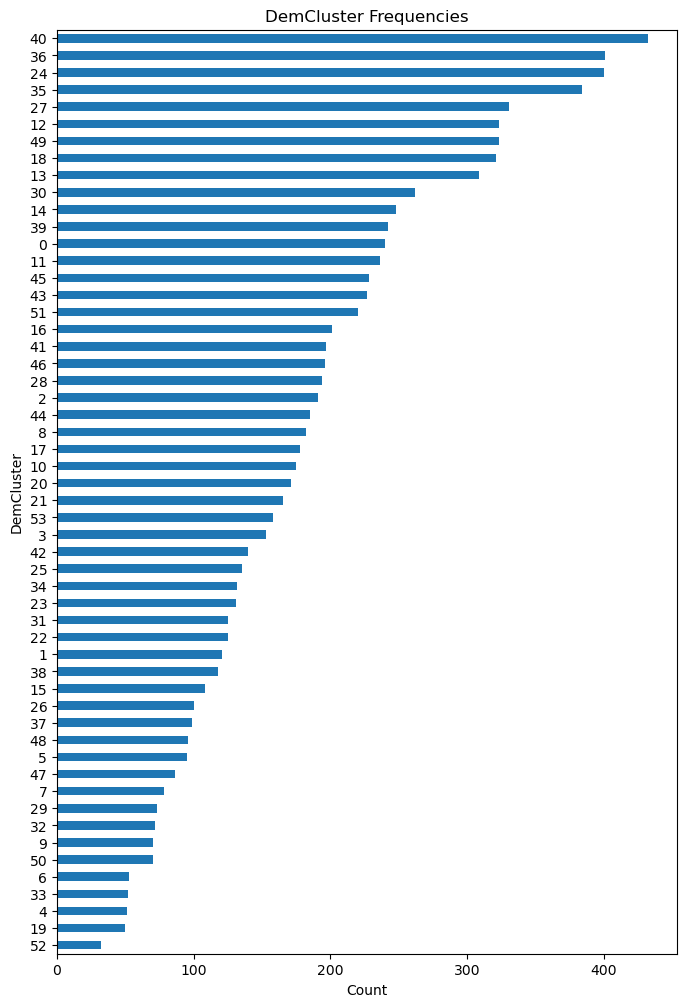

In [9]:
df["DemCluster"].value_counts().sort_values().plot(
    kind="barh",figsize=(8,12)
)
plt.xlabel("Count")
plt.title("DemCluster Frequencies")
plt.show()

### Question

If `DemCluster` has $k$ levels, how many dummy variables would it contribute if one reference level is omitted?

**Your response:**  
- k-1 model df

In [ ]:
## Suppose we want to keep the top 4 most frequent DemCluster
#### df['DemCluster40'] = (df['DemCluster'] == '40').astype(int)
## repeat for the rest: 36, 24, 35
## drop the original DemCluster and just keep the created dummy vars
## 3 model df as opposed 53 model df

---
# 5. Method 1 — Keep the Most Common Levels

A simple **unsupervised** approach:

1. rank categories by frequency
2. retain the most common
3. combine the remainder into `"Other"`

This reduces dimensions without using the response variable.

In [10]:
# TODO
top10_clusters= df['DemCluster'].value_counts().head(10).index

print("Top 10 clusters:",top10_clusters)

Top 10 clusters: Index([40, 36, 24, 35, 27, 12, 49, 18, 13, 30], dtype='object', name='DemCluster')


In [11]:
# TODO
df["DemCluster_Reduced"]=np.where(
     df["DemCluster"].isin(top10_clusters),
     df["DemCluster"].astype(str),
     "Other"
)

df["DemCluster_Reduced"].value_counts()

DemCluster_Reduced
Other    6199
40        432
36        401
24        400
35        384
27        331
12        323
49        323
18        321
13        309
30        262
Name: count, dtype: int64

In [12]:
## Let's delete it (will use other ways)
df.drop('DemCluster_Reduced', axis = 1, inplace = True)

## Practice 5A — Compare df before and after

In [13]:
# TODO
### if you reduce to 10 levels
original_dummy_df=53
reduced_dummy_df=10

print("Original dummy df:",original_dummy_df)
print("Reduced dummy df:",reduced_dummy_df)

Original dummy df: 53
Reduced dummy df: 10


### Limitation

A rare category could still be highly predictive. Frequency alone does not measure usefulness for predicting the target.

---
# 6. Method 2 — Let a Model Identify Important Levels

A tree-based model can use `TARGET_B` to identify levels that help distinguish donors from non-donors.

This is **supervised dimension reduction** because the response is used.

In [14]:
cluster_df=df[["TARGET_B","DemCluster"]].copy()
cluster_df

,TARGET_B,DemCluster
0,0,0
1,0,23
2,1,0
3,1,0
4,0,35
...,...,...
9680,1,44
9681,0,44
9682,1,40
9683,0,40


In [15]:
cluster_encoded=pd.get_dummies(
    cluster_df,
    columns=["DemCluster"],
    drop_first=False, ## one-hot
    dtype=int
)
cluster_encoded

,TARGET_B,DemCluster_0,DemCluster_1,DemCluster_2,DemCluster_3,DemCluster_4,DemCluster_5,DemCluster_6,DemCluster_7,DemCluster_8,DemCluster_9,DemCluster_10,DemCluster_11,DemCluster_12,DemCluster_13,DemCluster_14,DemCluster_15,DemCluster_16,DemCluster_17,DemCluster_18,DemCluster_19,DemCluster_20,DemCluster_21,DemCluster_22,DemCluster_23,DemCluster_24,DemCluster_25,DemCluster_26,DemCluster_27,DemCluster_28,DemCluster_29,DemCluster_30,DemCluster_31,DemCluster_32,DemCluster_33,DemCluster_34,DemCluster_35,DemCluster_36,DemCluster_37,DemCluster_38,DemCluster_39,DemCluster_40,DemCluster_41,DemCluster_42,DemCluster_43,DemCluster_44,DemCluster_45,DemCluster_46,DemCluster_47,DemCluster_48,DemCluster_49,DemCluster_50,DemCluster_51,DemCluster_52,DemCluster_53
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9680,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9681,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9682,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
9683,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [16]:
## STEP 1: CREATE A DATA SET WITH ONLY y = TARGET_B, AND THE CATEGORICAL VARIABLE TO REDUCE x = DemCluster
cluster_df=df[["TARGET_B","DemCluster"]].copy()

## STEP 2: ONE=HOT ENCODE x
cluster_encoded=pd.get_dummies(
    cluster_df,
    columns=["DemCluster"],
    drop_first=False, ## one-hot
    dtype=int
)

## STEP 3: CREATE X (MATRIX) AND y VECTOR FOR SUPERVISED ENSEMBLE MODEL (PREFERRED: rf, XGboost)
X_cluster=cluster_encoded.drop(columns="TARGET_B")
y_cluster=cluster_encoded["TARGET_B"]

print(X_cluster.shape)
X_cluster.head()

(9685, 54)


,DemCluster_0,DemCluster_1,DemCluster_2,DemCluster_3,DemCluster_4,DemCluster_5,DemCluster_6,DemCluster_7,DemCluster_8,DemCluster_9,DemCluster_10,DemCluster_11,DemCluster_12,DemCluster_13,DemCluster_14,DemCluster_15,DemCluster_16,DemCluster_17,DemCluster_18,DemCluster_19,DemCluster_20,DemCluster_21,DemCluster_22,DemCluster_23,DemCluster_24,DemCluster_25,DemCluster_26,DemCluster_27,DemCluster_28,DemCluster_29,DemCluster_30,DemCluster_31,DemCluster_32,DemCluster_33,DemCluster_34,DemCluster_35,DemCluster_36,DemCluster_37,DemCluster_38,DemCluster_39,DemCluster_40,DemCluster_41,DemCluster_42,DemCluster_43,DemCluster_44,DemCluster_45,DemCluster_46,DemCluster_47,DemCluster_48,DemCluster_49,DemCluster_50,DemCluster_51,DemCluster_52,DemCluster_53
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Practice 6A — Decision tree

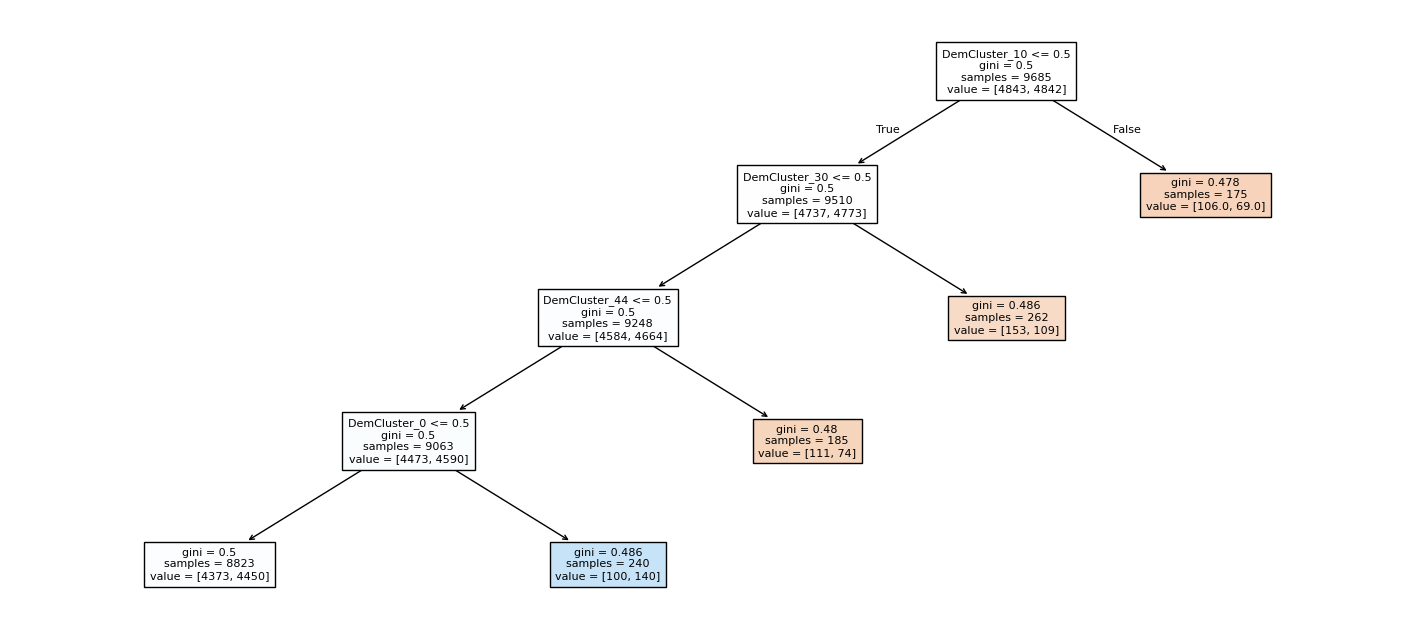

In [17]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

dt=DecisionTreeClassifier(max_depth=4,random_state=591)

# TODO
dt.fit(X_cluster,y_cluster)

plt.figure(figsize=(18,8))
plot_tree(dt,feature_names=X_cluster.columns,filled=True,fontsize=8)
plt.show()

### Interpretation

Why might a category that appears in the tree be more useful than one selected only because it is common?

**Your response:**  
-

## Practice 6B — Random forest importance

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=200,  ## use the most trees possible
    random_state=591,
    n_jobs=-1          ## multi-core processing
)

# TODO
rf.fit(X_cluster,y_cluster)

importance=pd.DataFrame({
    "Level":X_cluster.columns,
    "Importance":rf.feature_importances_
}).sort_values("Importance",ascending=False)

importance.head(10)  ## top 10 levels

,Level,Importance
10,DemCluster_10,0.065876
30,DemCluster_30,0.062167
44,DemCluster_44,0.053719
0,DemCluster_0,0.049337
41,DemCluster_41,0.041011
32,DemCluster_32,0.039320
47,DemCluster_47,0.033892
36,DemCluster_36,0.029216
8,DemCluster_8,0.028373
40,DemCluster_40,0.025945


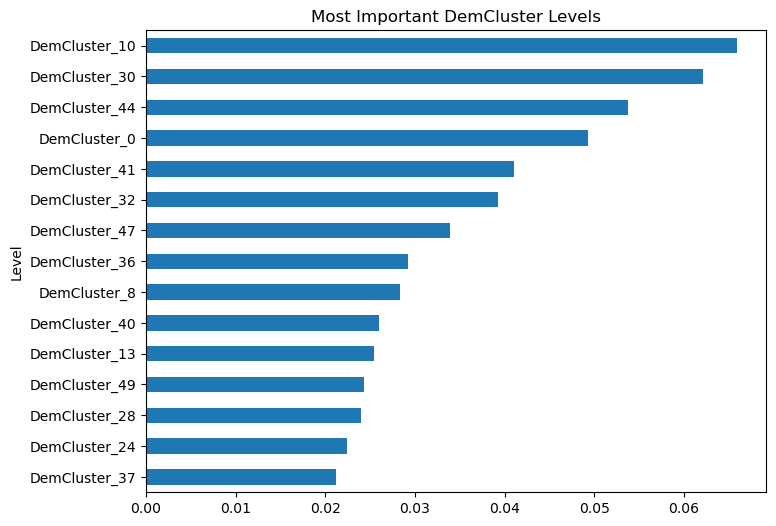

In [19]:
# TODO
importance.head(15).sort_values("Importance").plot(
     x="Level",y="Importance",kind="barh",
    legend=False,figsize=(8,6)
)
plt.title("Most Important DemCluster Levels")
plt.show()

### Important

Frequency-based reduction does **not** use $y$. Tree/RF reduction **does** use $y$.

When evaluating a predictive model, supervised feature selection should ultimately be learned from the **training data only**.

In [20]:
## Let's keep the top 4 levels (most/least likely to donate based on the RF)
df['DemCluster10'] = (df['DemCluster'] == "10").astype(int)
df['DemCluster30'] = (df['DemCluster'] == "30").astype(int)
df['DemCluster44'] = (df['DemCluster'] == "44").astype(int)
df['DemCluster0'] = (df['DemCluster'] == "0").astype(int)
## we do not need to create "other" category (we assume the base/ref)

df.drop(columns = "DemCluster", inplace = True)

In [21]:
## data is ready for modeling
df.to_csv('data/veterans_model_data.csv', index = False)

---
# 7. Reducing Redundancy in Numeric Variables

Numeric variables generally contribute one df each. The primary reason to reduce them is often **redundancy**.

Highly correlated predictors may contain overlapping information.

In [ ]:
num=df.select_dtypes(include=np.number)

corr=num.corr()
upper=np.triu(np.ones(corr.shape),k=1).astype(bool)

corr_pairs=(
    corr.abs()
        .where(upper)
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(15)

## Practice 7A — Find highly correlated pairs

In [ ]:
# TODO
high_corr_pairs=None

# Hint: keep pairs above a threshold such as .90
high_corr_pairs

### Question

If two predictors have $|r|=.99$, what could you do? What information would you consider before choosing which one to retain?

**Your response:**  
-

---
# 8. Feature Selection vs. Feature Extraction

### Feature selection
Keep some original predictors.

Examples:
- domain knowledge
- correlation screening
- tree/RF importance

### Feature extraction
Create new predictors that summarize the originals.

Example:
- **Principal Component Analysis (PCA)**

PCA is the focus of Worksheet 2.

## Practice 8A — Complete the table

| Method | Selection or Extraction? | Uses target $y$? |
|---|---|---|
| Remove ID |  |  |
| Keep most common categories |  |  |
| Random-forest importance |  |  |
| Correlation screening |  |  |
| PCA |  |  |

---
# 9. Final Challenge

A dataset has:

- 3,000 observations
- 150 numeric predictors
- one categorical predictor with 200 levels
- several highly correlated predictor groups
- an ID
- a predictor available only after the outcome

Write a dimension-reduction plan with at least four actions.

**Your plan:**  
-

## Exit Ticket

Why is dimension reduction about **preserving useful information**, not simply making a dataset smaller?

**Your response:**  
-